### MTG sélection par celltype

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import anndata as ad
import scanpy as sc

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
mpl.rcParams["figure.figsize"] = (6, 5)

print(f"scanpy  {sc.__version__}")
print(f"anndata {ad.__version__}")

scanpy  1.10.3
anndata 0.10.9


In [2]:
DATA_PATH = "../data/raw/SEAAD_MTG_ATACseq_all-nuclei.2024-12-06.h5ad"

adata = sc.read_h5ad(DATA_PATH)
print(adata)
print("\n--- obs columns ---")
print(adata.obs.columns.tolist())

AnnData object with n_obs × n_vars = 1123761 × 218882
    obs: 'sample_id', 'Neurotypical reference', 'Donor ID', 'Organism', 'Brain Region', 'Sex', 'Gender', 'Age at Death', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'PMI', 'Fresh Brain Weight', 'Brain pH', 'Overall AD neuropathological Change', 'Thal', 'Braak', 'CERAD score', 'Overall CAA Score', 'Highest Lewy Body Disease', 'Total Microinfarcts (not observed grossly)', 'Total microinfarcts in screening sections', 'Atherosclerosis', 'Arteriolosclerosis', 'LATE', 'Cognitive Status', 'Last CASI Score', 'Interval from last CASI in months', 'Last MMSE Score', 'Interval from last MMSE in months', 'Last MOCA Score', 'Interval from last MOCA in m

In [3]:
qc_cols = [
    'ATAC_Median_high_quality_fragments_per_cell',
    'ATAC_TSS_enrichment_score',
    'ATAC_Fraction_of_high_quality_fragments_overlapping_TSS',
    'ATAC_Fraction_of_high_quality_fragments_overlapping_peaks',
    'ATAC_Percent_duplicates',
    'Doublet score',
    'Fraction mitochondrial UMIs',
]

# Conversion en numérique
for col in qc_cols:
    adata.obs[col] = pd.to_numeric(adata.obs[col], errors='coerce')

print("=== Stats descriptives QC ===")
print(adata.obs[qc_cols].describe().round(3))


=== Stats descriptives QC ===
       ATAC_Median_high_quality_fragments_per_cell  ATAC_TSS_enrichment_score  \
count                                  1123761.000                1123761.000   
mean                                     39400.636                      4.579   
std                                      19415.343                      0.679   
min                                         18.000                      2.608   
25%                                      26081.000                      4.175   
50%                                      36681.500                      4.577   
75%                                      51241.000                      5.010   
max                                      99374.000                      6.245   

       ATAC_Fraction_of_high_quality_fragments_overlapping_TSS  \
count                                        1123761.000         
mean                                               0.214         
std                                       

In [4]:
adata.obs['log10_fragments'] = np.log10(
    adata.obs['ATAC_Median_high_quality_fragments_per_cell'] + 1
)
adata.obs['tss_score']  = adata.obs['ATAC_TSS_enrichment_score']
adata.obs['frac_peaks'] = adata.obs['ATAC_Fraction_of_high_quality_fragments_overlapping_peaks']
adata.obs['frac_tss']   = adata.obs['ATAC_Fraction_of_high_quality_fragments_overlapping_TSS']
adata.obs['pct_dup']    = adata.obs['ATAC_Percent_duplicates']



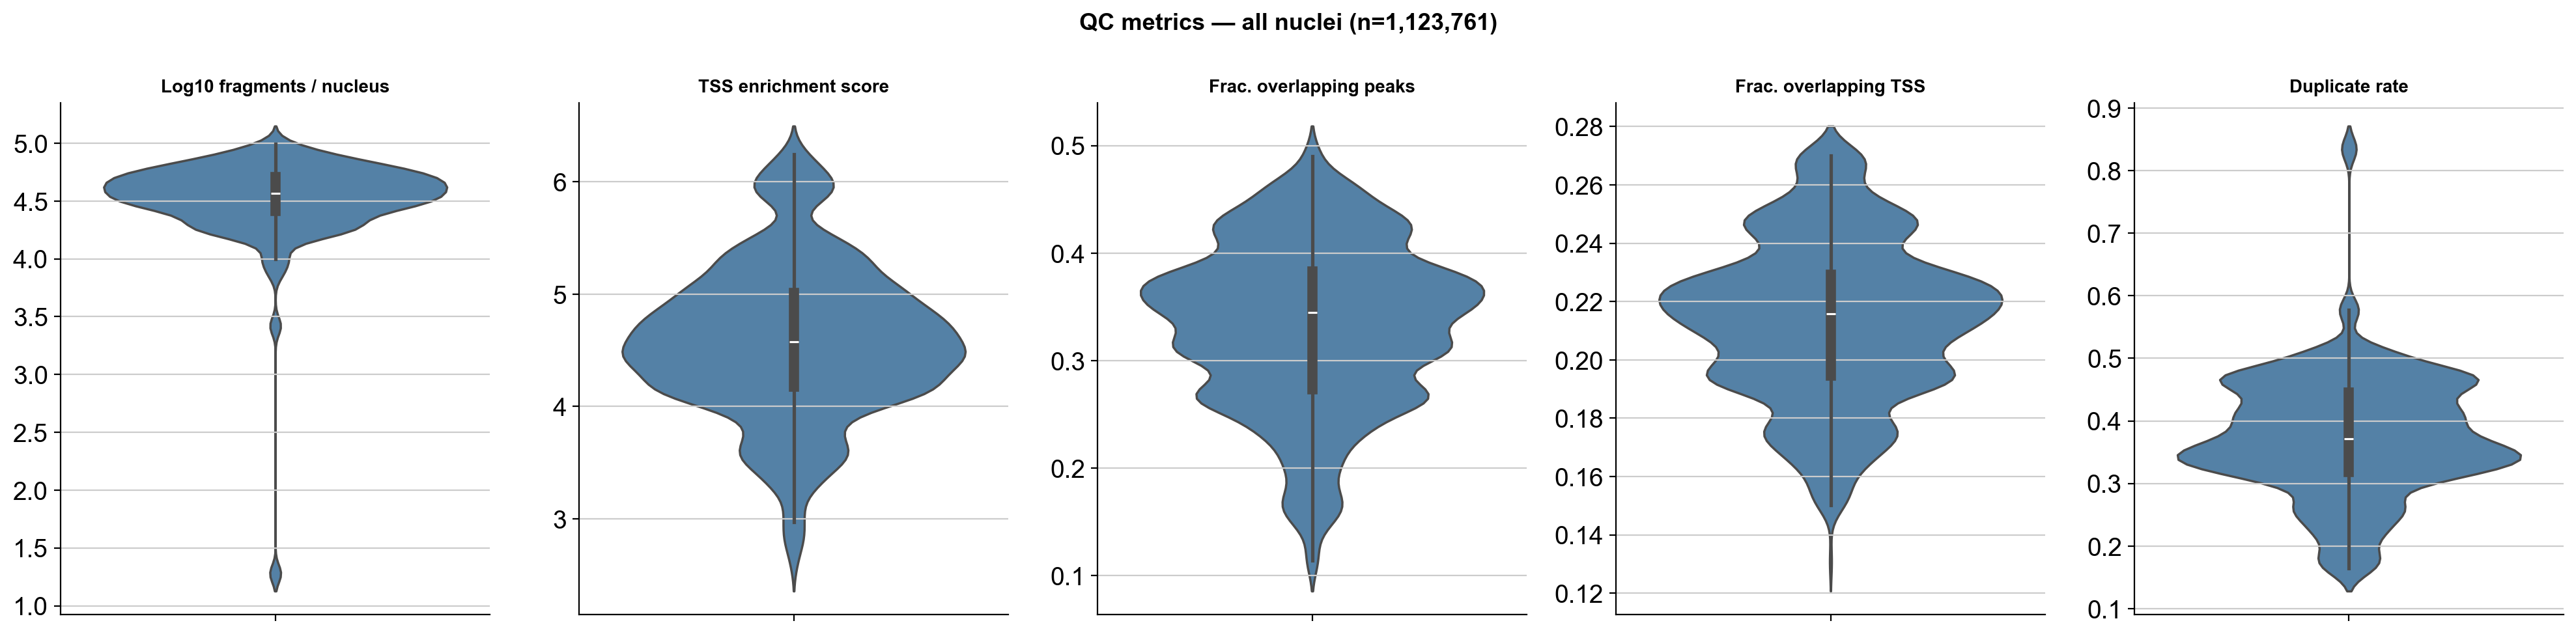

In [5]:
qc_metrics = {
    'log10_fragments' : 'Log10 fragments / nucleus',
    'tss_score'       : 'TSS enrichment score',
    'frac_peaks'      : 'Frac. overlapping peaks',
    'frac_tss'        : 'Frac. overlapping TSS',
    'pct_dup'         : 'Duplicate rate',
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('QC metrics — all nuclei (n=1,123,761)', fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, qc_metrics.items()):
    sns.violinplot(
        data=adata.obs, y=col, ax=ax,
        color='steelblue', inner='box',
        bw_adjust=3
    )
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


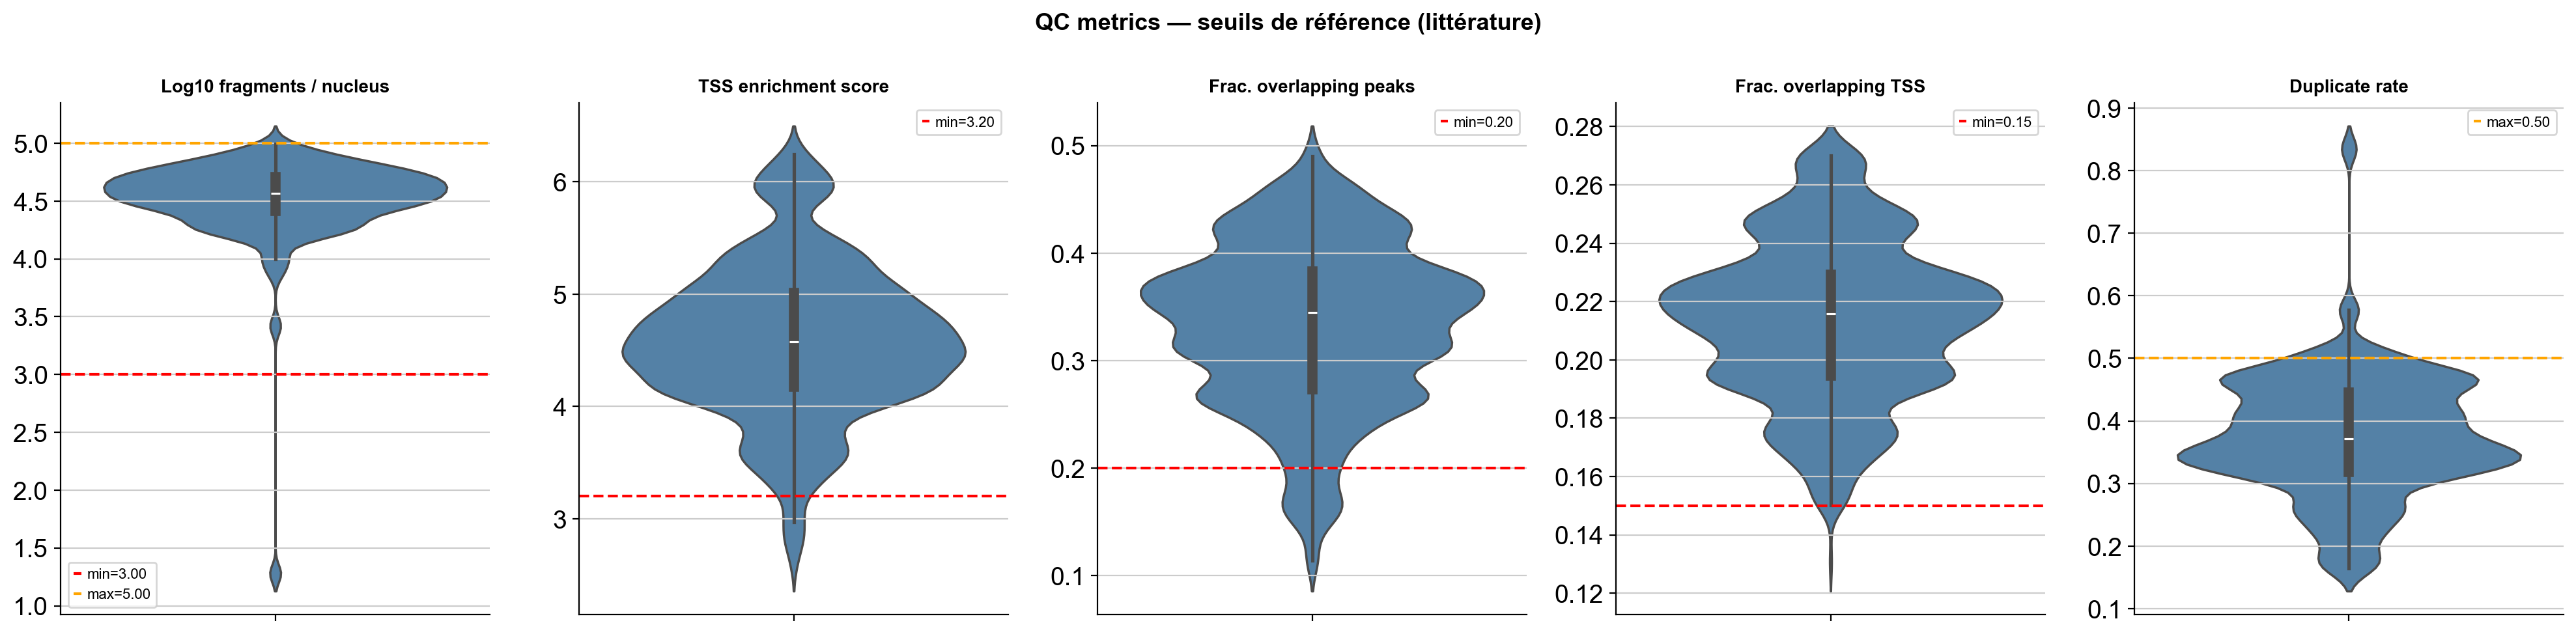

In [6]:
# Seuils standards snATAC-seq (littérature)
thresholds = {
    'log10_fragments' : {'min': np.log10(1000), 'max': np.log10(100000)},
    'tss_score'       : {'min': 3.2,    'max': None},
    'frac_peaks'      : {'min': 0.2, 'max': None},
    'frac_tss'        : {'min': 0.15, 'max': None},
    'pct_dup'         : {'min': None, 'max': 0.5},
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('QC metrics — seuils de référence (littérature)', fontsize=13, fontweight='bold')

labels = {
    'log10_fragments' : 'Log10 fragments / nucleus',
    'tss_score'       : 'TSS enrichment score',
    'frac_peaks'      : 'Frac. overlapping peaks',
    'frac_tss'        : 'Frac. overlapping TSS',
    'pct_dup'         : 'Duplicate rate',
}

for ax, col in zip(axes, thresholds.keys()):
    sns.violinplot(
        data=adata.obs, y=col, ax=ax,
        color='steelblue', inner='box',
        bw_adjust=3
    )
    # Ligne min en rouge
    if thresholds[col]['min'] is not None:
        ax.axhline(thresholds[col]['min'], color='red', linestyle='--', 
                   linewidth=1.5, label=f"min={thresholds[col]['min']:.2f}")
    # Ligne max en orange
    if thresholds[col]['max'] is not None:
        ax.axhline(thresholds[col]['max'], color='orange', linestyle='--', 
                   linewidth=1.5, label=f"max={thresholds[col]['max']:.2f}")
    
    ax.set_title(labels[col], fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()


In [7]:
seuils = {
    'log10_fragments' : ('min', np.log10(1000)),
    'tss_score'       : ('min', 3.2),
    'frac_peaks'      : ('min', 0.2),
    'frac_tss'        : ('min', 0.15),
    'pct_dup'         : ('max', 0.50),
}

print(f"Total noyaux de départ : {adata.n_obs:,}\n")
mask_keep = pd.Series(True, index=adata.obs_names)

for col, (direction, val) in seuils.items():
    vals = adata.obs[col]
    if direction == 'min':
        crit = vals >= val
    else:
        crit = vals <= val

    # NaN comptés comme échec du critère
    crit = crit.fillna(False)
    n_fail = (~crit).sum()
    pct = n_fail / adata.n_obs * 100
    print(f"{col:<20} {direction}={val:.2f} → exclut {n_fail:>7,} noyaux ({pct:.1f}%)")

    mask_keep &= crit

n_keep = int(mask_keep.sum())
n_excl = adata.n_obs - n_keep
print("\n--- Filtre combiné (tous les seuils) ---")
print(f"Noyaux restants : {n_keep:,} / {adata.n_obs:,} ({n_keep/adata.n_obs*100:.1f}%)")
print(f"Noyaux exclus   : {n_excl:,} ({n_excl/adata.n_obs*100:.1f}%)")

Total noyaux de départ : 1,123,761

log10_fragments      min=3.00 → exclut  11,307 noyaux (1.0%)
tss_score            min=3.20 → exclut  23,932 noyaux (2.1%)
frac_peaks           min=0.20 → exclut  65,974 noyaux (5.9%)
frac_tss             min=0.15 → exclut   1,314 noyaux (0.1%)
pct_dup              max=0.50 → exclut  79,723 noyaux (7.1%)

--- Filtre combiné (tous les seuils) ---
Noyaux restants : 971,269 / 1,123,761 (86.4%)
Noyaux exclus   : 152,492 (13.6%)


In [8]:
# Appliquer le masque QC
adata_qc = adata[mask_keep]
print(f"Après QC : {adata_qc.n_obs:,} noyaux")

# Sélectionner les neurones
neuron_gaba = ['Neuronal: GABAergic']
neuron_glut = ['Neuronal: Glutamatergic']

mask_neurons_glu = adata_qc.obs['Class'].isin(neuron_glut)
mask_neurons_gaba = adata_qc.obs['Class'].isin(neuron_gaba)

adata_neurons_glu = adata_qc[mask_neurons_glu] 
adata_neurons_gaba = adata_qc[mask_neurons_gaba]

print(f"\nAprès sélection neurones glutamatergiques :")
print(f"  Total    : {adata_neurons_glu.n_obs:,}")
print(adata_neurons_glu.obs['Class'].value_counts())
print(f"\nDonors uniques : {adata_neurons_glu.obs['Donor ID'].nunique()}")

print(f"\nAprès sélection neurones gabaergiques :")
print(f"  Total    : {adata_neurons_gaba.n_obs:,}")
print(adata_neurons_gaba.obs['Class'].value_counts())
print(f"\nDonors uniques : {adata_neurons_gaba.obs['Donor ID'].nunique()}")




Après QC : 971,269 noyaux

Après sélection neurones glutamatergiques :
  Total    : 679,386
Class
Neuronal: Glutamatergic    679386
Name: count, dtype: int64

Donors uniques : 75

Après sélection neurones gabaergiques :
  Total    : 175,528
Class
Neuronal: GABAergic    175528
Name: count, dtype: int64

Donors uniques : 75


In [9]:
import gc
del adata, adata_qc
gc.collect()
print("\nadata et adata_qc supprimés de la mémoire.")


adata et adata_qc supprimés de la mémoire.



=== Glutamatergic ===
nombre de donors : 75
Noyaux par donor :
  Min     : 3,384
  Médiane : 6,361
  Max     : 25,244
  Donors < 500 noyaux  : 0
  Donors < 1000 noyaux : 0


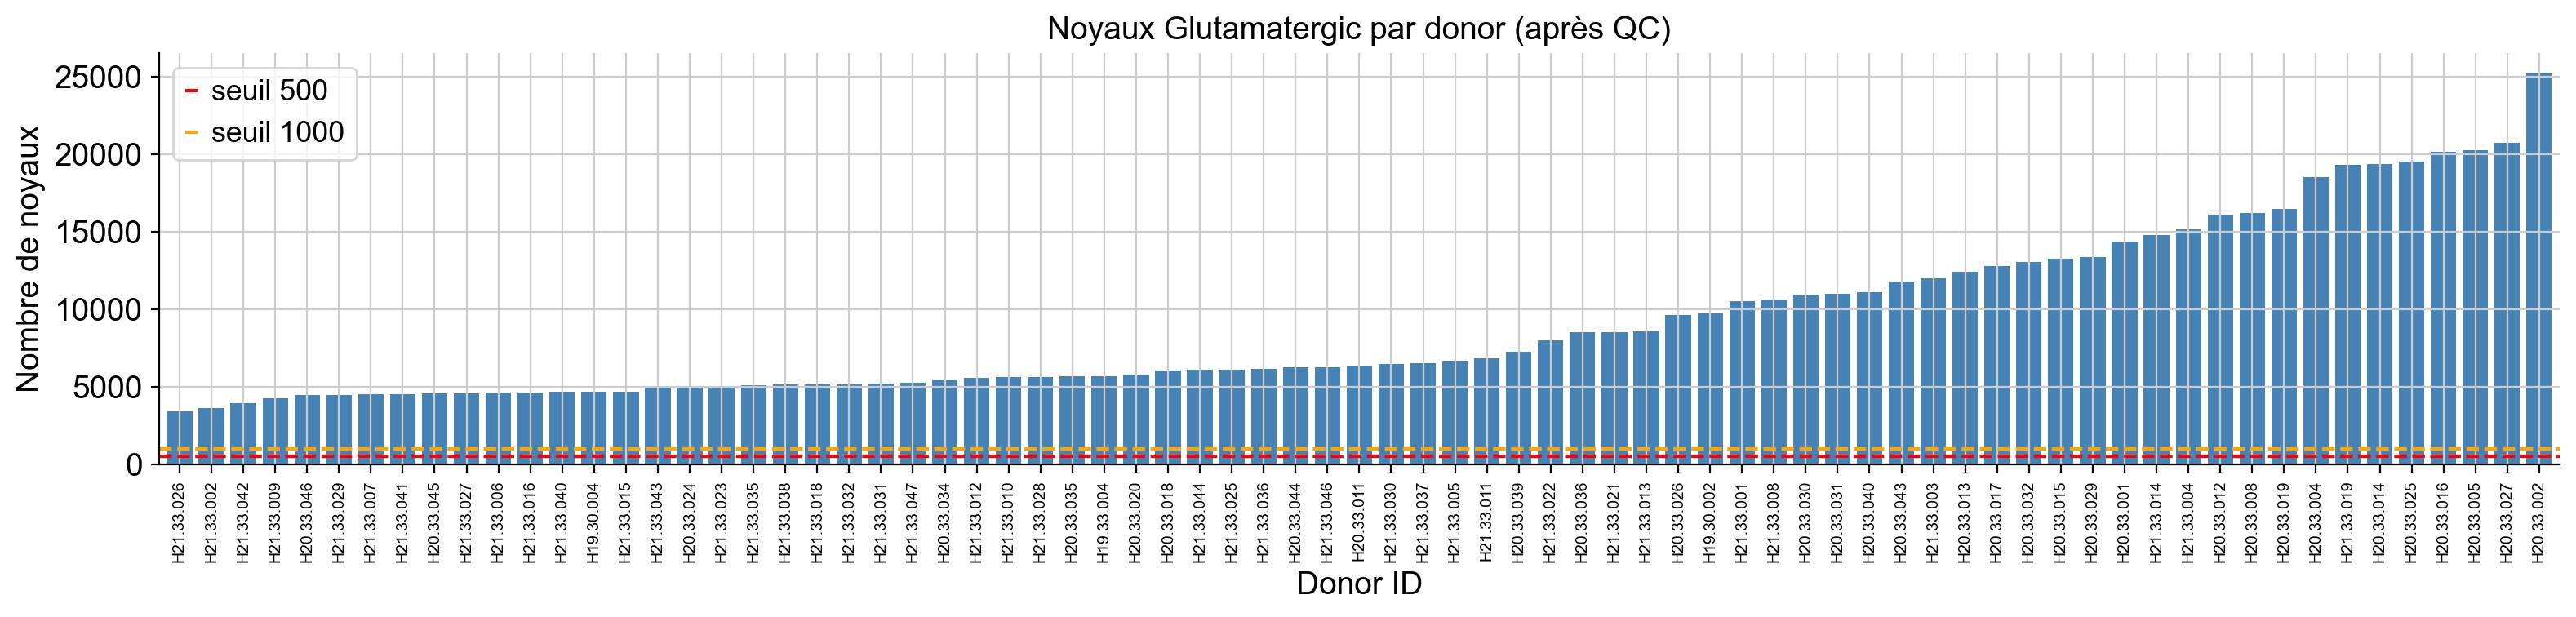


=== GABAergic ===
nombre de donors : 75
Noyaux par donor :
  Min     : 438
  Médiane : 1,713
  Max     : 7,322
  Donors < 500 noyaux  : 1
  Donors < 1000 noyaux : 9


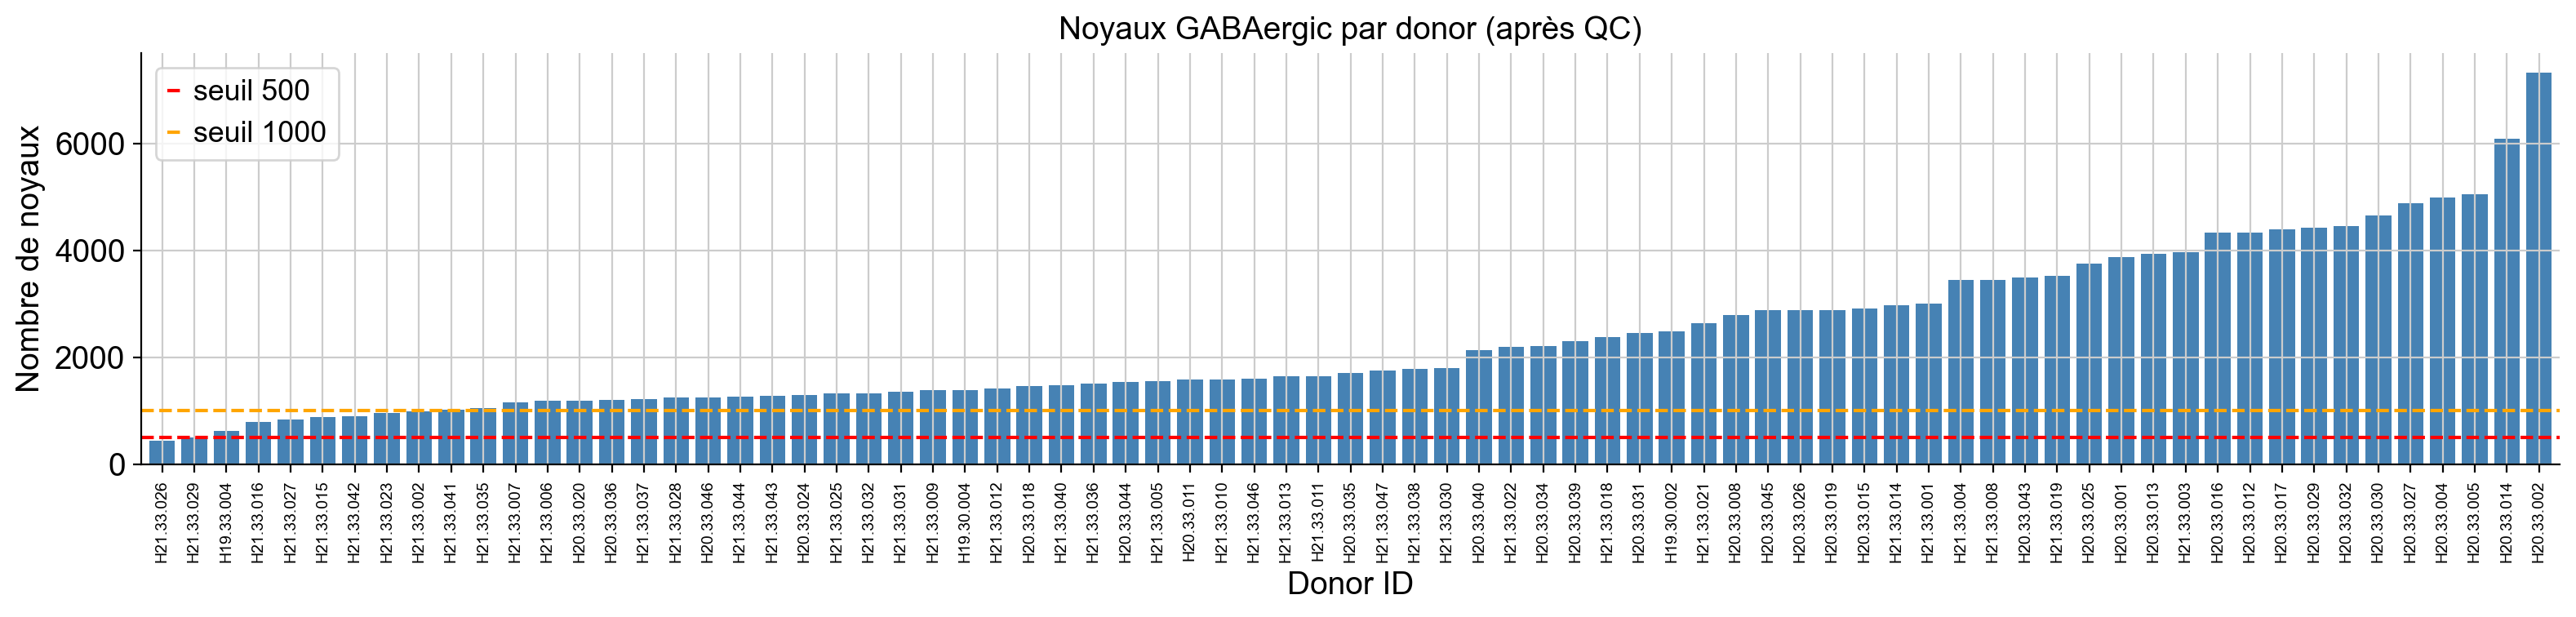

In [10]:

for label, adata_neurons in [('Glutamatergic', adata_neurons_glu), ('GABAergic', adata_neurons_gaba)]:
    nuclei_per_donor = adata_neurons.obs.groupby('Donor ID').size().sort_values()
    print(f"\n=== {label} ===")
    print(f"nombre de donors : {nuclei_per_donor.size}")
    print("Noyaux par donor :")
    print(f"  Min     : {nuclei_per_donor.min():,}")
    print(f"  Médiane : {nuclei_per_donor.median():,.0f}")
    print(f"  Max     : {nuclei_per_donor.max():,}")
    print(f"  Donors < 500 noyaux  : {(nuclei_per_donor < 500).sum()}")
    print(f"  Donors < 1000 noyaux : {(nuclei_per_donor < 1000).sum()}")

    fig, ax = plt.subplots(figsize=(16, 4))
    nuclei_per_donor.plot(kind='bar', ax=ax, color='steelblue', width=0.8)
    ax.axhline(500,  color='red',    linestyle='--', linewidth=1.5, label='seuil 500')
    ax.axhline(1000, color='orange', linestyle='--', linewidth=1.5, label='seuil 1000')
    ax.set_xlabel('Donor ID')
    ax.set_ylabel('Nombre de noyaux')
    ax.set_title(f'Noyaux {label} par donor (après QC)')
    ax.legend()
    ax.set_xticklabels(nuclei_per_donor.index, rotation=90, fontsize=7)
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig(f'qc_03_nuclei_per_donor_{label.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [12]:

# Une ligne par donor avec ses covariables cliniques
# On utilise les glutamatergiques pour extraire la méta
donor_meta_glu = adata_neurons_glu.obs.groupby('Donor ID').first()[[
    'Cognitive Status', 
    'Braak', 
    'APOE Genotype',
    'Brain pH',
    'Continuous Pseudo-progression Score',
    'Sex',
    'Age at Death',
]].copy()

# Conversion numérique
donor_meta_glu['Pseudo_score'] = pd.to_numeric(
    donor_meta_glu['Continuous Pseudo-progression Score'], errors='coerce'
)
donor_meta_glu['Braak_num'] = pd.to_numeric(donor_meta_glu['Braak'], errors='coerce')

print("=== Distribution Cognitive Status ===")
print(donor_meta_glu['Cognitive Status'].value_counts())

print("\n=== Pseudo-progression Score ===")
print(donor_meta_glu['Pseudo_score'].describe().round(3))

print("\n=== Sex ===")
print(donor_meta_glu['Sex'].value_counts())


=== Distribution Cognitive Status ===
Cognitive Status
No dementia    41
Dementia       32
Reference       2
Name: count, dtype: int64

=== Pseudo-progression Score ===
count    73.000
mean      0.592
std       0.248
min       0.150
25%       0.356
50%       0.678
75%       0.811
max       0.929
Name: Pseudo_score, dtype: float64

=== Sex ===
Sex
Female    42
Male      33
Name: count, dtype: int64


In [14]:

# Une ligne par donor avec ses covariables cliniques
# On utilise les GABAergiques pour extraire la méta
donor_meta_gaba = adata_neurons_gaba.obs.groupby('Donor ID').first()[[
    'Cognitive Status', 
    'Braak', 
    'APOE Genotype',
    'Brain pH',
    'Continuous Pseudo-progression Score',
    'Sex',
    'Age at Death',
]].copy()

# Conversion numérique
donor_meta_gaba['Pseudo_score'] = pd.to_numeric(
    donor_meta_gaba['Continuous Pseudo-progression Score'], errors='coerce'
)
donor_meta_gaba['Braak_num'] = pd.to_numeric(donor_meta_gaba['Braak'], errors='coerce')

print("=== Distribution Cognitive Status ===")
print(donor_meta_gaba['Cognitive Status'].value_counts())

print("\n=== Pseudo-progression Score ===")
print(donor_meta_gaba['Pseudo_score'].describe().round(3))

print("\n=== Sex ===")
print(donor_meta_gaba['Sex'].value_counts())


=== Distribution Cognitive Status ===
Cognitive Status
No dementia    41
Dementia       32
Reference       2
Name: count, dtype: int64

=== Pseudo-progression Score ===
count    73.000
mean      0.592
std       0.248
min       0.150
25%       0.356
50%       0.678
75%       0.811
max       0.929
Name: Pseudo_score, dtype: float64

=== Sex ===
Sex
Female    42
Male      33
Name: count, dtype: int64


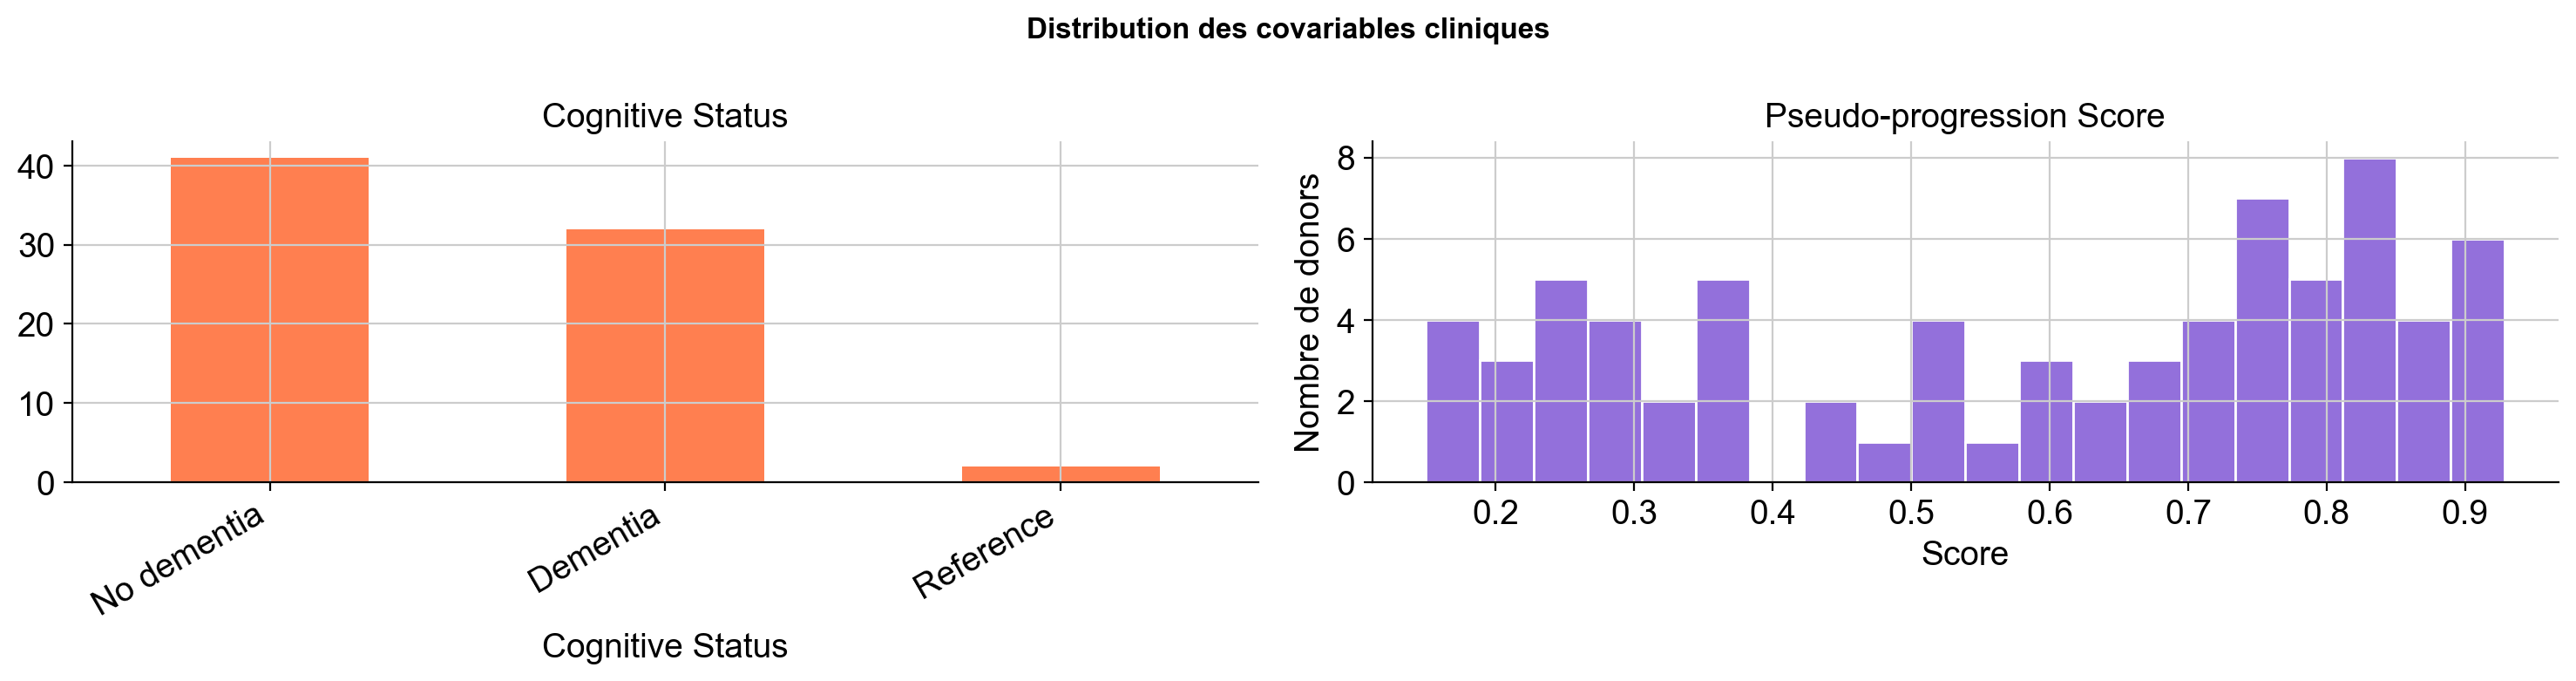

In [15]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle('Distribution des covariables cliniques', 
             fontsize=12, fontweight='bold')

donor_meta_glu['Cognitive Status'].value_counts().plot(
    kind='bar', ax=axes[0], color='coral'
)
axes[0].set_title('Cognitive Status')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
sns.despine(ax=axes[0])

axes[1].hist(donor_meta_glu['Pseudo_score'].dropna(), bins=20, color='mediumpurple', edgecolor='white')
axes[1].set_title('Pseudo-progression Score')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Nombre de donors')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

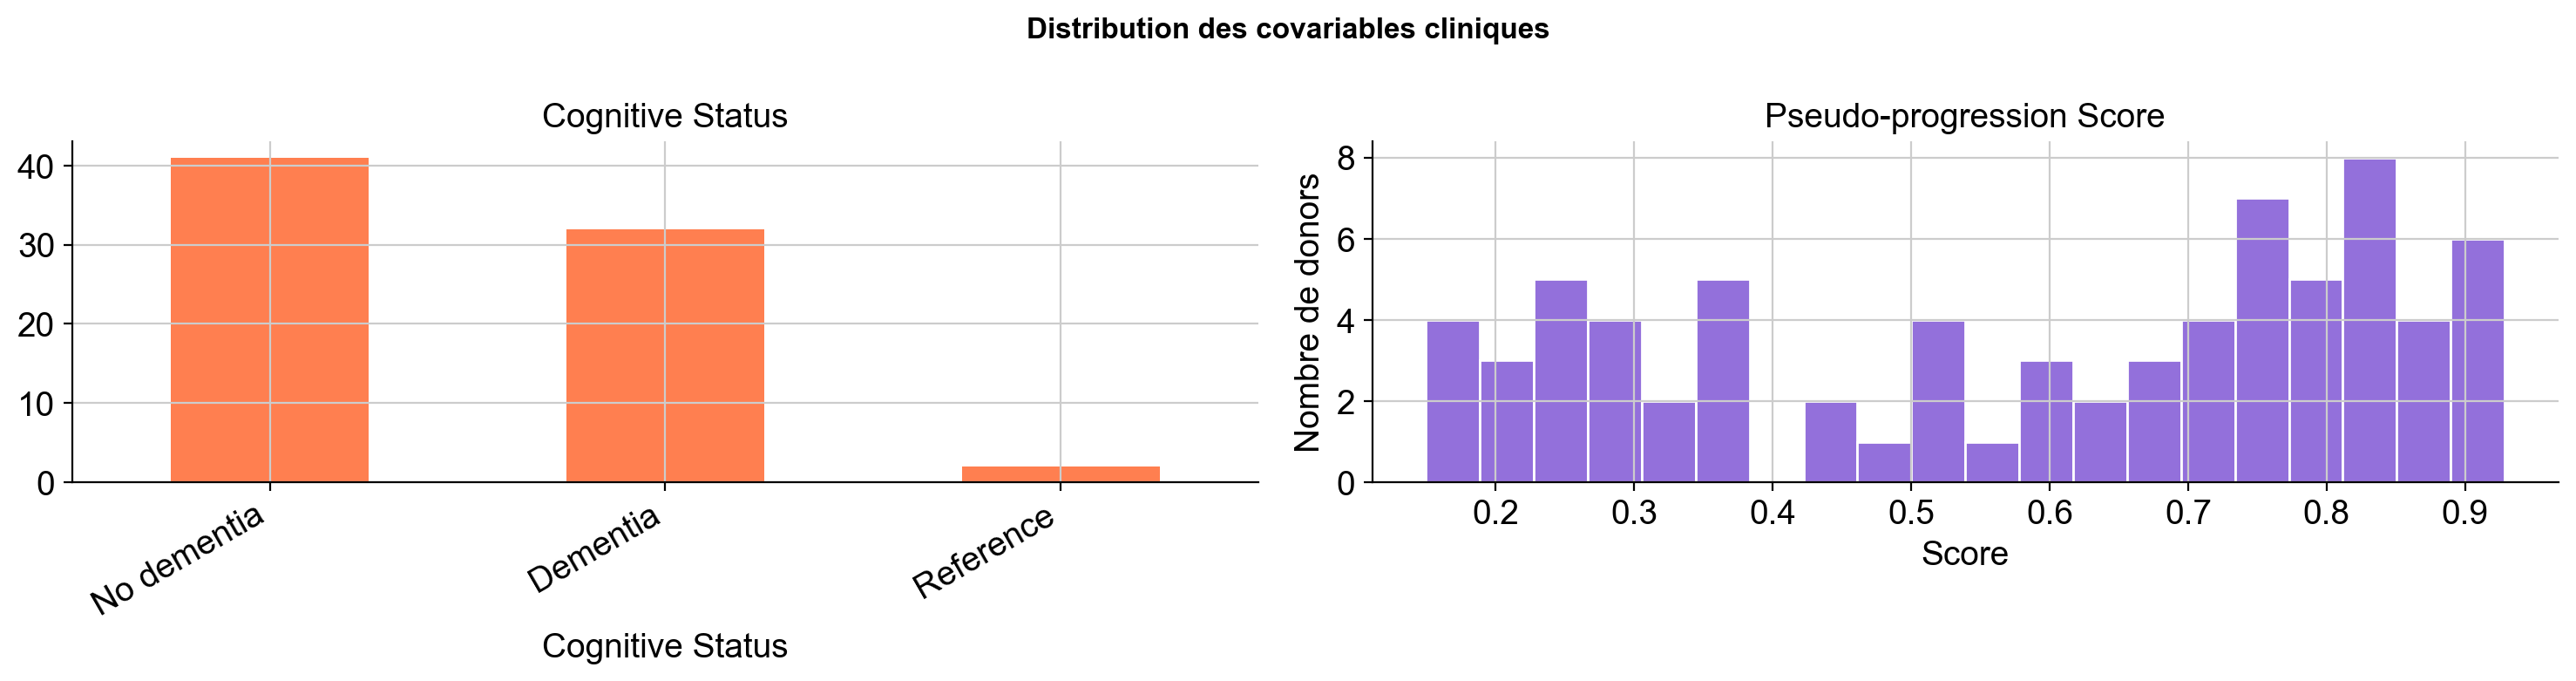

In [16]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.suptitle('Distribution des covariables cliniques', 
             fontsize=12, fontweight='bold')

donor_meta_gaba['Cognitive Status'].value_counts().plot(
    kind='bar', ax=axes[0], color='coral'
)
axes[0].set_title('Cognitive Status')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')
sns.despine(ax=axes[0])

axes[1].hist(donor_meta_gaba['Pseudo_score'].dropna(), bins=20, color='mediumpurple', edgecolor='white')
axes[1].set_title('Pseudo-progression Score')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Nombre de donors')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

In [17]:

import scipy.sparse as sp

def make_pseudobulk(adata, label):
    donors = adata.obs['Donor ID'].unique()
    print(f"Construction du pseudobulk {label} pour {len(donors)} donors...")
    pb_matrix = []
    for donor in donors:
        mask = adata.obs['Donor ID'] == donor
        donor_counts = adata[mask].X
        if sp.issparse(donor_counts):
            pb_matrix.append(np.array(donor_counts.sum(axis=0)).flatten())
        else:
            pb_matrix.append(donor_counts.sum(axis=0))
    pb_matrix = np.array(pb_matrix)
    print(f"  → {pb_matrix.shape[0]} donors × {pb_matrix.shape[1]:,} peaks")
    print(f"  Counts min/max par donor : {pb_matrix.sum(axis=1).min():,.0f} / {pb_matrix.sum(axis=1).max():,.0f}")
    return pb_matrix, donors

pb_matrix_glu,  donors_glu  = make_pseudobulk(adata_neurons_glu,  'Glutamatergic')
pb_matrix_gaba, donors_gaba = make_pseudobulk(adata_neurons_gaba, 'GABAergic')

# Sauvegarder les infos nécessaires avant suppression
var_df = adata_neurons_glu.var.copy()   # peaks identiques entre les deux types

meta_cols = ['Sex', 'Age at Death', 'PMI', 'Brain pH', 'Cognitive Status',
             'Continuous Pseudo-progression Score', 'APOE Genotype']
obs_meta_glu  = adata_neurons_glu.obs.groupby('Donor ID').first()[meta_cols].copy()
obs_meta_gaba = adata_neurons_gaba.obs.groupby('Donor ID').first()[meta_cols].copy()

# Libérer les matrices de noyaux — le pseudobulk est construit
del adata_neurons_glu, adata_neurons_gaba
gc.collect()
print("\nadata_neurons_glu et adata_neurons_gaba supprimés de la mémoire.")


Construction du pseudobulk Glutamatergic pour 75 donors...
  → 75 donors × 218,882 peaks
  Counts min/max par donor : 136,289,760 / 1,217,449,472
Construction du pseudobulk GABAergic pour 75 donors...
  → 75 donors × 218,882 peaks
  Counts min/max par donor : 30,140,540 / 251,384,240

adata_neurons_glu et adata_neurons_gaba supprimés de la mémoire.


In [18]:

# Intersection des donors communs aux deux types cellulaires
common_donors = sorted(set(donors_glu) & set(donors_gaba))
print(f"Donors GLU     : {len(donors_glu)}")
print(f"Donors GABA    : {len(donors_gaba)}")
print(f"Donors communs : {len(common_donors)}")
only_glu  = set(donors_glu)  - set(donors_gaba)
only_gaba = set(donors_gaba) - set(donors_glu)
if only_glu:
    print(f"  → exclus (GLU seulement)  : {sorted(only_glu)}")
if only_gaba:
    print(f"  → exclus (GABA seulement) : {sorted(only_gaba)}")

# Filtrer les matrices pseudobulk aux donors communs
idx_glu  = [list(donors_glu).index(d)  for d in common_donors]
idx_gaba = [list(donors_gaba).index(d) for d in common_donors]
pb_matrix_glu_common  = pb_matrix_glu[idx_glu]
pb_matrix_gaba_common = pb_matrix_gaba[idx_gaba]

# Métadonnées cliniques — donors communs uniquement (GLU et GABA doivent être cohérents)
donor_meta_common = obs_meta_glu.loc[common_donors].copy()
for col in ['Age at Death', 'PMI', 'Brain pH', 'Continuous Pseudo-progression Score']:
    donor_meta_common[col] = pd.to_numeric(donor_meta_common[col], errors='coerce')

# AnnData pseudobulk glutamatergique
adata_pb_glu = ad.AnnData(
    X=pb_matrix_glu_common,
    obs=donor_meta_common.copy(),
    var=var_df,
)
adata_pb_glu.obs_names = common_donors

# AnnData pseudobulk gabaergique
adata_pb_gaba = ad.AnnData(
    X=pb_matrix_gaba_common,
    obs=donor_meta_common.copy(),
    var=var_df,
)
adata_pb_gaba.obs_names = common_donors

print("\n=== Glutamatergique ===")
print(adata_pb_glu)
print("\n=== GABAergique ===")
print(adata_pb_gaba)
print("\n=== Covariables numériques ===")
print(donor_meta_common[['Age at Death', 'PMI', 'Brain pH',
                          'Continuous Pseudo-progression Score']].describe().round(2))


Donors GLU     : 75
Donors GABA    : 75
Donors communs : 75

=== Glutamatergique ===
AnnData object with n_obs × n_vars = 75 × 218882
    obs: 'Sex', 'Age at Death', 'PMI', 'Brain pH', 'Cognitive Status', 'Continuous Pseudo-progression Score', 'APOE Genotype'

=== GABAergique ===
AnnData object with n_obs × n_vars = 75 × 218882
    obs: 'Sex', 'Age at Death', 'PMI', 'Brain pH', 'Cognitive Status', 'Continuous Pseudo-progression Score', 'APOE Genotype'

=== Covariables numériques ===
       Age at Death    PMI  Brain pH  Continuous Pseudo-progression Score
count         73.00  73.00     73.00                                73.00
mean          88.84   6.92      6.73                                 0.59
std            8.09   2.27      0.32                                 0.25
min           65.00   3.20      6.20                                 0.15
25%           84.00   5.00      6.40                                 0.36
50%           90.00   6.92      6.70                                

In [19]:

# count_matrix_glu.txt : peaks × donors communs glutamatergiques
pb_df_glu = pd.DataFrame(
    adata_pb_glu.X.T,
    index=adata_pb_glu.var_names,
    columns=adata_pb_glu.obs_names,
).astype(int)

pb_df_glu.to_csv('../data/processed/count_matrix_glu.txt', sep='\t')
print(f"count_matrix_glu.txt : {pb_df_glu.shape[0]:,} peaks × {pb_df_glu.shape[1]} donors")
print(pb_df_glu.iloc[:3, :3])

# count_matrix_gaba.txt : peaks × donors communs gabaergiques
pb_df_gaba = pd.DataFrame(
    adata_pb_gaba.X.T,
    index=adata_pb_gaba.var_names,
    columns=adata_pb_gaba.obs_names,
).astype(int)

pb_df_gaba.to_csv('../data/processed/count_matrix_gaba.txt', sep='\t')
print(f"\ncount_matrix_gaba.txt : {pb_df_gaba.shape[0]:,} peaks × {pb_df_gaba.shape[1]} donors")
print(pb_df_gaba.iloc[:3, :3])

# metadata.txt : metadata clinique des donors communs aux deux types
meta_df = adata_pb_glu.obs.copy()
meta_df.index.name = 'Sample'
meta_df.to_csv('../data/metadata/metadata.txt', sep='\t')
print(f"\nmetadata.txt : {meta_df.shape[0]} donors communs × {meta_df.shape[1]} colonnes")
print(meta_df.head(3))


count_matrix_glu.txt : 218,882 peaks × 75 donors
                          H19.30.002  H19.30.004  H19.33.004
chr4:164130572-164131513         432         465         938
chr4:16412872-16415576          1931        1609        2555
chr4:164116366-164116739          83          71         222

count_matrix_gaba.txt : 218,882 peaks × 75 donors
                          H19.30.002  H19.30.004  H19.33.004
chr4:164130572-164131513          24          34          40
chr4:16412872-16415576            81          58          55
chr4:164116366-164116739           9          13          21

metadata.txt : 75 donors communs × 7 colonnes
               Sex  Age at Death       PMI  Brain pH Cognitive Status  \
Sample                                                                  
H19.30.002    Male           NaN       NaN       NaN        Reference   
H19.30.004    Male           NaN       NaN       NaN        Reference   
H19.33.004  Female          80.0  8.133333       7.0      No dementia   


In [20]:
# Encoder Sex en numérique
meta_df['Sex'] = meta_df['Sex'].map({'Female': 0, 'Male': 1})
meta_df.to_csv('../data/metadata/metadata.txt', sep='\t')
print("\nmetadata.txt mis à jour")
print(meta_df.head(3))


metadata.txt mis à jour
           Sex  Age at Death       PMI  Brain pH Cognitive Status  \
Sample                                                              
H19.30.002   1           NaN       NaN       NaN        Reference   
H19.30.004   1           NaN       NaN       NaN        Reference   
H19.33.004   0          80.0  8.133333       7.0      No dementia   

            Continuous Pseudo-progression Score APOE Genotype  
Sample                                                         
H19.30.002                                  NaN           NaN  
H19.30.004                                  NaN           NaN  
H19.33.004                             0.302313           3/3  


In [21]:

def peak_sort_key(peak):
    chrom, coords = peak.split(':')
    start = int(coords.split('-')[0])
    c = chrom.replace('chr', '')
    chrom_num = int(c) if c.isdigit() else {'X': 23, 'Y': 24, 'M': 25}.get(c, 99)
    return (chrom_num, start)

# Les peaks sont identiques entre glu et gaba (même adata source)
sorted_idx = sorted(pb_df_glu.index.tolist(), key=peak_sort_key)

pb_df_glu  = pb_df_glu.loc[sorted_idx]
pb_df_gaba = pb_df_gaba.loc[sorted_idx]

pb_df_glu.to_csv('../data/processed/count_matrix_glu.txt',  sep='\t')
pb_df_gaba.to_csv('../data/processed/count_matrix_gaba.txt', sep='\t')

print("Peaks triés — 5 premiers :", sorted_idx[:5])


Peaks triés — 5 premiers : ['chr1:180742-181572', 'chr1:190803-191893', 'chr1:267958-268038', 'chr1:605375-605629', 'chr1:629906-629979']


In [22]:

meta_df.columns = meta_df.columns.str.replace(' ', '_')
meta_df.to_csv('../data/metadata/metadata.txt', sep='\t')
print(meta_df.columns.tolist())


['Sex', 'Age_at_Death', 'PMI', 'Brain_pH', 'Cognitive_Status', 'Continuous_Pseudo-progression_Score', 'APOE_Genotype']


In [23]:

import pandas as pd

data_glu  = pd.read_csv('../data/processed/count_matrix_glu.txt',  sep='\t', index_col=0)
data_gaba = pd.read_csv('../data/processed/count_matrix_gaba.txt', sep='\t', index_col=0)

print("GLU  :", data_glu.shape)
print("GABA :", data_gaba.shape)
display(data_glu.iloc[:3, :3])
display(data_gaba.iloc[:3, :3])


GLU  : (218882, 75)
GABA : (218882, 75)


,H19.30.002,H19.30.004,H19.33.004
chr1:180742-181572,638,313,209
chr1:190803-191893,605,812,1758
chr1:267958-268038,91,78,144


,H19.30.002,H19.30.004,H19.33.004
chr1:180742-181572,98,42,10
chr1:190803-191893,495,573,289
chr1:267958-268038,10,17,8


In [24]:
metadata = pd.read_csv('../data/metadata/metadata.txt', sep='\t', index_col=0)

In [25]:

meta_samples = set(metadata.index.tolist())

for label, data in [('GLU', data_glu), ('GABA', data_gaba)]:
    cm_samples = set(data.columns.tolist())
    print(f"=== {label} ===")
    print(f"  Intersection avec metadata : {len(cm_samples & meta_samples)}")
    print(f"  Exemple count_matrix : {repr(data.columns[0])}")
    print(f"  Exemple metadata     : {repr(metadata.index[0])}")


=== GLU ===
  Intersection avec metadata : 75
  Exemple count_matrix : 'H19.30.002'
  Exemple metadata     : 'H19.30.002'
=== GABA ===
  Intersection avec metadata : 75
  Exemple count_matrix : 'H19.30.002'
  Exemple metadata     : 'H19.30.002'


In [26]:

import subprocess

# Exporter sans nommer l'index (tab vide en tête = format attendu par R)
data_glu.index.name  = None
data_gaba.index.name = None

data_glu.to_csv('../data/processed/count_matrix_glu.txt',  sep='\t')
data_gaba.to_csv('../data/processed/count_matrix_gaba.txt', sep='\t')

for fname in ['count_matrix_glu.txt', 'count_matrix_gaba.txt']:
    result = subprocess.run(
        ['head', '-1', f'../data/processed/{fname}'],
        capture_output=True, text=True
    )
    print(f"{fname}: {result.stdout[:80]}")


count_matrix_glu.txt: 	H19.30.002	H19.30.004	H19.33.004	H20.33.001	H20.33.002	H20.33.004	H20.33.005	H2
count_matrix_gaba.txt: 	H19.30.002	H19.30.004	H19.33.004	H20.33.001	H20.33.002	H20.33.004	H20.33.005	H2


In [27]:

import subprocess

refs = ['H19.30.002', 'H19.30.004']

for label, df, fname in [
    ('GLU',  data_glu,  'count_matrix_glu.txt'),
    ('GABA', data_gaba, 'count_matrix_gaba.txt'),
]:
    df = df.drop(columns=[r for r in refs if r in df.columns])
    df = df.astype(int)
    df.index.name = None
    df.to_csv(f'../data/processed/{fname}', sep='\t')
    head = subprocess.run(['head', '-1', f'../data/processed/{fname}'], capture_output=True, text=True).stdout[:60]
    print(f"{label} | {fname} | shape={df.shape} | dtype={df.dtypes.iloc[0]}")
    print(f"  header: {head}")

# Mettre à jour les variables en mémoire
data_glu  = df if label == 'GLU'  else data_glu   # noqa
data_gaba = df if label == 'GABA' else data_gaba  # noqa
# Ré-assigner proprement
data_glu  = pd.read_csv('../data/processed/count_matrix_glu.txt',  sep='\t', index_col=0)
data_gaba = pd.read_csv('../data/processed/count_matrix_gaba.txt', sep='\t', index_col=0)
print(f"\nGLU  : {data_glu.shape} | GABA : {data_gaba.shape}")


GLU | count_matrix_glu.txt | shape=(218882, 73) | dtype=int64
  header: 	H19.33.004	H20.33.001	H20.33.002	H20.33.004	H20.33.005	H20.
GABA | count_matrix_gaba.txt | shape=(218882, 73) | dtype=int64
  header: 	H19.33.004	H20.33.001	H20.33.002	H20.33.004	H20.33.005	H20.

GLU  : (218882, 73) | GABA : (218882, 73)
